# Using WhiteSet for Quality Control
<a id="using-whitesets"></a>

The `WhiteSet` class allows you to protect specific observations from being flagged as outliers during quality control checks. Whitelisted records **participate in all QC calculations** (means, standard deviations, etc.) but are **protected from being flagged as outliers** in the final results.

This is useful when you know certain records are valid despite appearing anomalous, such as:
- Known extreme weather events
- Validated station-specific conditions
- Records that have been manually verified

This notebook demonstrates how to use `WhiteSet` with the quality control methods of the `Dataset` and `Station` classes.

## Import and Setup

First, import the toolkit and load demo data.

In [1]:
import metobs_toolkit
import pandas as pd
import copy

# Import demo dataset
dataset = metobs_toolkit.Dataset()
dataset.import_data_from_file(
    input_data_file=metobs_toolkit.demo_datafile,
    input_metadata_file=metobs_toolkit.demo_metadatafile,
    template_file=metobs_toolkit.demo_template,
)

# Resample to hourly for consistent QC
dataset.resample(target_freq='1h')

print(f"Dataset contains {len(dataset.stations)} stations")

Luchtdruk is present in the datafile, but not found in the template! This column will be ignored.
Neerslagintensiteit is present in the datafile, but not found in the template! This column will be ignored.
Neerslagsom is present in the datafile, but not found in the template! This column will be ignored.
Rukwind is present in the datafile, but not found in the template! This column will be ignored.
Luchtdruk_Zeeniveau is present in the datafile, but not found in the template! This column will be ignored.
Globe Temperatuur is present in the datafile, but not found in the template! This column will be ignored.
The following columns are present in the data file, but not in the template! They are skipped!
 ['Luchtdruk', 'Luchtdruk_Zeeniveau', 'Rukwind', 'Neerslagintensiteit', 'Globe Temperatuur', 'Neerslagsom']
The following columns are found in the metadata, but not in the template and are therefore ignored: 
['sponsor', 'stad', 'Network', 'benaming']
The present gaps are removed, new gap

Dataset contains 28 stations


## Baseline QC without WhiteSet

Let's run a gross value check to identify outliers without any whitelisting.

<Axes: title={'center': 'Gross Value Check without Whitelisting'}, xlabel='Timestamps (in UTC)', ylabel='temp (degree_Celsius)'>

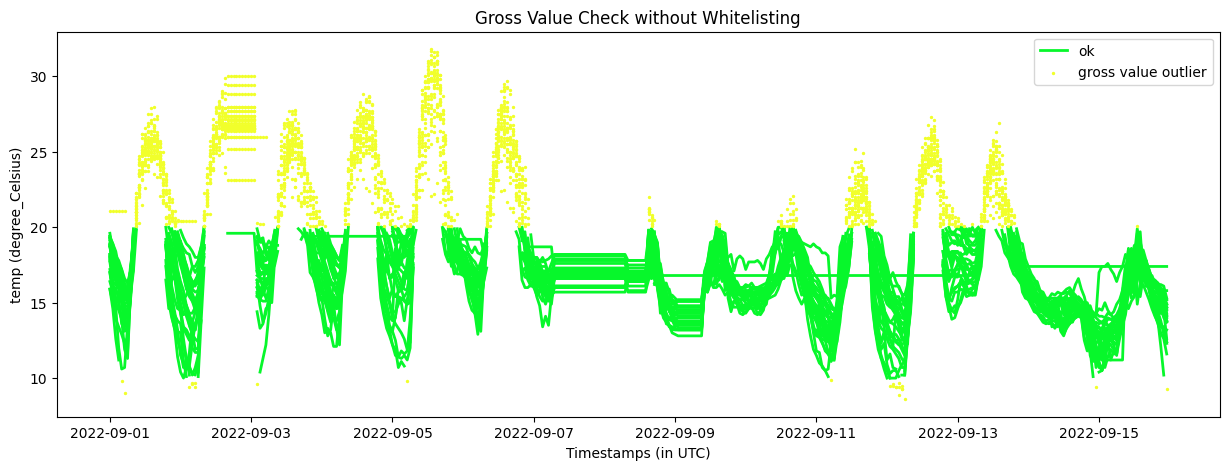

In [2]:
baseline_dataset = copy.deepcopy(dataset)
# Apply gross value check without whitelisting
baseline_dataset.gross_value_check(
    obstype='temp',
    lower_threshold=10.0,
    upper_threshold=20.0,
    use_mp=False
)

# View outliers
baseline_dataset.make_plot(obstype='temp', colorby='label', title='Gross Value Check without Whitelisting')


## Creating a WhiteSet

A `WhiteSet` is created from a pandas Index or MultiIndex with one or more of these levels:
- **datetime**: Specific timestamps to whitelist
- **name**: Station names
- **obstype**: Observation types

Let's create different types of WhiteSets and examine them using the `get_info()` method.

### WhiteSet with datetime only

This whitelists specific timestamps across **all stations** and **all observation types**.

In [3]:
# Specify timestamps

white_timestamps = pd.date_range(start='2022-09-03 01:00',
                                 end='2022-09-05 18:00',
                                 freq='1h',
                                 tz='UTC'
                                 )

# Create WhiteSet with datetime-only index
whiteset_dt = metobs_toolkit.WhiteSet(
    pd.Index(white_timestamps, name='datetime')
)

# View information about this WhiteSet
whiteset_dt.get_info()

                            General info of WhiteSet                            


--- Whitelist details ---

  -Total records: 66
  -Index levels: datetime
  -Unique timestamps: 66
  -Time range: 2022-09-03 01:00:00+00:00 to 2022-09-05 18:00:00+00:00



## Using WhiteSet in Dataset QC Methods

Now let's apply the same QC check with whitelisting and compare the results.

<Axes: title={'center': 'temp data.'}, xlabel='Timestamps (in UTC)', ylabel='temp (degree_Celsius)'>

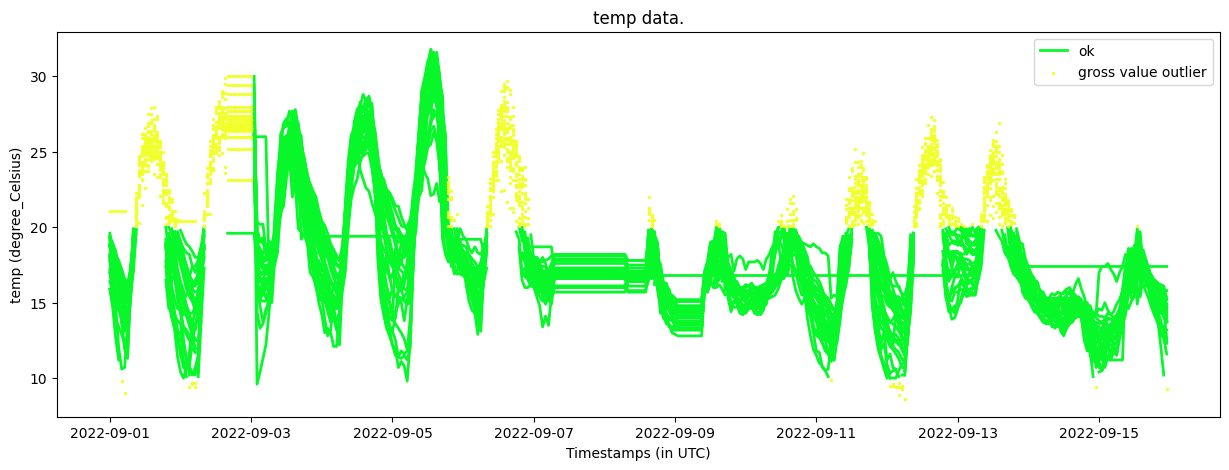

In [4]:
# Create a fresh dataset copy
dataset_with_whitelist = copy.deepcopy(dataset)


# Apply gross value check WITH whitelisting
dataset_with_whitelist.gross_value_check(
    obstype='temp',
    lower_threshold=10.0,
    upper_threshold=20.0,
    whiteset=whiteset_dt,
    use_mp=False
)

dataset_with_whitelist.make_plot(obstype='temp', colorby='label')

As can be seen, all records in the whitelisted timestamps period are 'saved' and not labeled as outliers.

## WhiteSet with name-only index

If you only provide a 'name' index to the `WhiteSet`, then none of the records of that station are flagged by a QC check if the whiteset is provided.

<Axes: title={'center': 'temp data.'}, xlabel='Timestamps (in UTC)', ylabel='temp (degree_Celsius)'>

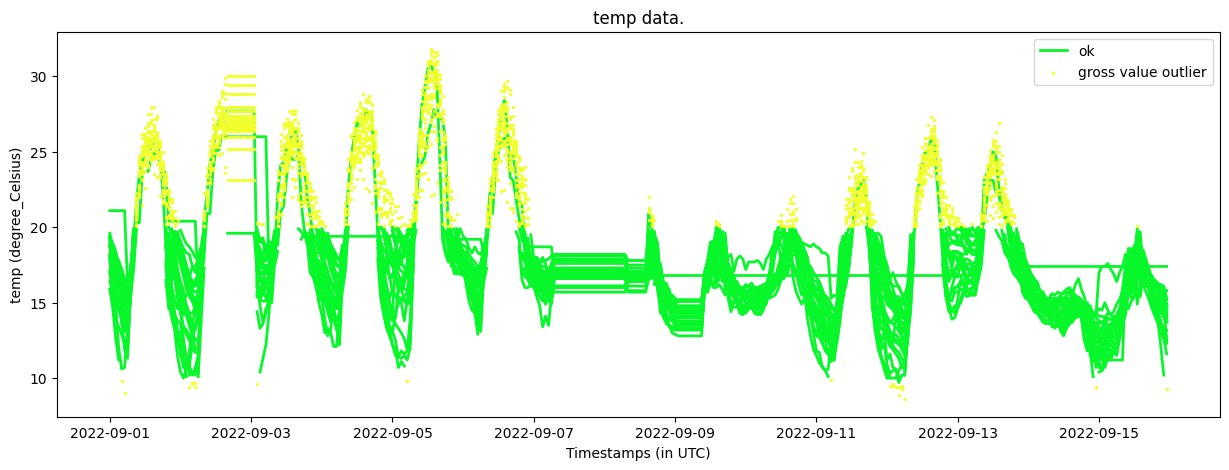

In [5]:
# Create a fresh dataset copy
dataset_with_whitelist = copy.deepcopy(dataset)

whiteset = metobs_toolkit.WhiteSet(
    pd.Index(['vlinder05', 'vlinder06'], name='name')
)   

# Apply gross value check WITH whitelisting
dataset_with_whitelist.gross_value_check(
    obstype='temp',
    lower_threshold=10.0,
    upper_threshold=20.0,
    whiteset=whiteset,
    use_mp=False
)

dataset_with_whitelist.make_plot(obstype='temp', colorby='label')

### WhiteSet from outliersdf with name and datetime

We can obtain more control by also specifying station name - timestamp pairs.
This whitelists specific timestamps for **specific stations** only.

In [6]:
# 1. Create a multi-index WhiteSet with name and datetime

# Get some outliers to use as examples
baseline_outliers = baseline_dataset.outliersdf
sample_outliers = baseline_outliers.reset_index().set_index(['name', 'datetime'])

# We take only a sample as demonstration
sample_outliers = sample_outliers.sample(n=42)

# Get the index
sample_outliers = sample_outliers.index

sample_outliers

MultiIndex([('vlinder10', '2022-09-02 12:00:00+00:00'),
            ('vlinder16', '2022-09-06 18:00:00+00:00'),
            ('vlinder26', '2022-09-06 13:00:00+00:00'),
            ('vlinder14', '2022-09-02 19:00:00+00:00'),
            ('vlinder06', '2022-09-05 12:00:00+00:00'),
            ('vlinder27', '2022-09-04 23:00:00+00:00'),
            ('vlinder15', '2022-09-06 19:00:00+00:00'),
            ('vlinder23', '2022-09-01 12:00:00+00:00'),
            ('vlinder17', '2022-09-12 13:00:00+00:00'),
            ('vlinder03', '2022-09-01 14:00:00+00:00'),
            ('vlinder25', '2022-09-06 13:00:00+00:00'),
            ('vlinder02', '2022-09-04 19:00:00+00:00'),
            ('vlinder18', '2022-09-05 13:00:00+00:00'),
            ('vlinder26', '2022-09-13 12:00:00+00:00'),
            ('vlinder25', '2022-09-04 15:00:00+00:00'),
            ('vlinder16', '2022-09-03 14:00:00+00:00'),
            ('vlinder21', '2022-09-06 18:00:00+00:00'),
            ('vlinder28', '2022-09-11 17:00:00+0

<Axes: title={'center': 'temp data.'}, xlabel='Timestamps (in UTC)', ylabel='temp (degree_Celsius)'>

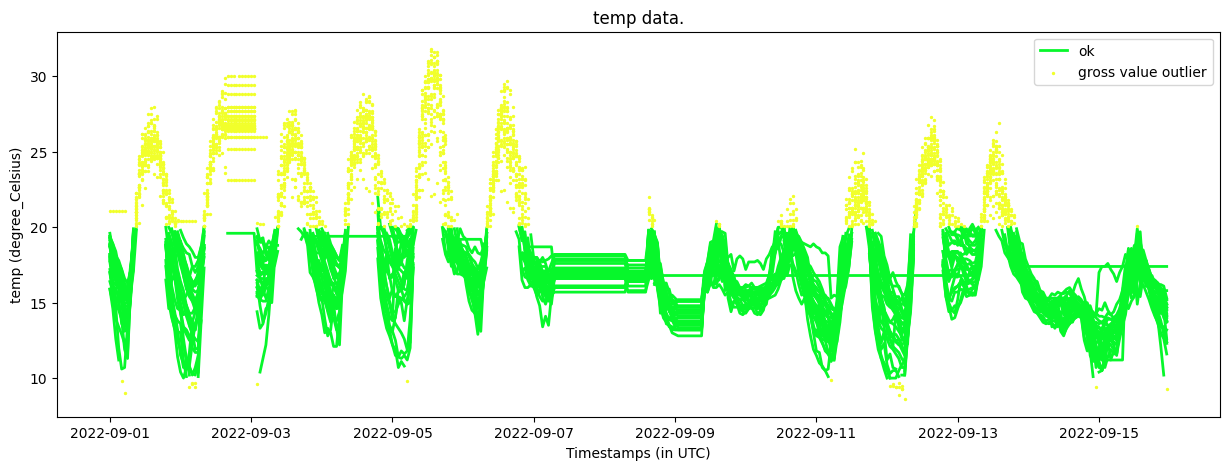

In [7]:
# 2. Create a WhiteSet from the index

whiteset = metobs_toolkit.WhiteSet(sample_outliers)

# 3. Apply it in QC
# Create a fresh dataset copy
dataset_with_specific_whitelist = copy.deepcopy(dataset)


# Apply gross value check WITH whitelisting
dataset_with_specific_whitelist.gross_value_check(
    obstype='temp',
    lower_threshold=10.0,
    upper_threshold=20.0,
    whiteset=whiteset,
    use_mp=False
)

dataset_with_specific_whitelist.make_plot(obstype='temp', colorby='label')

## Special Note for Buddy Check

**Important:** When using WhiteSet with `buddy_check()` or `buddy_check_with_safetynets()`, whitelisted records have a special behavior. Since buddy check is an iterative algorithm that compares each station's values against its spatial neighbors, **whitelisted records participate in every iteration** and **influence the statistical calculations** used to evaluate other stations.

This means that a whitelisted extreme value at one station can affect whether neighboring stations get flagged as outliers, since the extreme value remains in the reference dataset throughout all buddy check iterations. Consider this carefully when whitelisting records for spatial quality control methods.

## Key Points

- **WhiteSet protects records from being flagged**, but they still participate in calculations
- Works with all Dataset QC methods: `gross_value_check`, `persistence_check`, `repetitions_check`, `step_check`, `window_variation_check`, `buddy_check`, `buddy_check_with_safetynets`
- Works with all Station QC methods: `gross_value_check`, `persistence_check`, `repetitions_check`, `step_check`, `window_variation_check`
- Can whitelist by datetime, station name, obstype, or any combination
- Use `get_info()` to inspect WhiteSet contents
- Empty WhiteSet (default) means no protection